# Crossover Rate Experiment

This notebook investigates how the crossover rate influences the convergence 
of a Genetic Algorithm applied to image approximation using 100 semi-transparent 
triangles.

Six crossover rates are tested under identical conditions, with crossover type 
fixed as one-point, to measure the impact of recombination frequency on 
optimization performance.

In [ ]:

import matplotlib.pyplot as plt
import pandas as pd
from ga_core import *

# Reproducibilidade
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

## Configuration

All parameters below are fixed across the six experiments. Only the crossover 
rate varies, ensuring a fair and isolated comparison.

In [4]:
POP_SIZE = 30
GENERATIONS = 1000

ELITE_SIZE = 3
TOURNAMENT_SIZE = 5

CROSSOVER_RATES = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

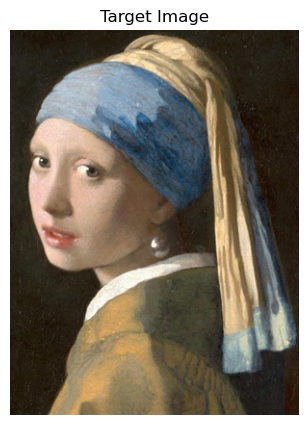

In [5]:
target = load_target_image("girl_pearl_earing.png")

plt.figure(figsize=(4, 5))
plt.imshow(target)
plt.title("Target Image")
plt.axis("off")
plt.show()

## Experiment Function

The function below runs the GA for each crossover rate. The crossover rate 
defines the probability of recombination occurring between two parents:

- `0.5` — crossover applied 50% of the time
- `0.6` — crossover applied 60% of the time
- `0.7` — crossover applied 70% of the time
- `0.8` — crossover applied 80% of the time
- `0.9` — crossover applied 90% of the time
- `1.0` — crossover always applied

When crossover does not occur, the child is a direct copy of one of the parents.

In [6]:
def run_crossover_rate_experiment(
    target_img,
    crossover_rates,
    pop_size=POP_SIZE,
    generations=GENERATIONS,
    elite_size=ELITE_SIZE,
    tournament_size=TOURNAMENT_SIZE
):
    """
    Runs the GA with different crossover rates.
    All other GA parameters remain constant.
    Crossover type is fixed as one_point (best performing from CrossoverTest).
    """
    results = {}

    for rate in crossover_rates:
        print("=" * 60)
        print(f"Testing crossover rate: {rate}")

        result = evolve_configurable(
            target_img=target_img,
            pop_size=pop_size,
            generations=generations,
            mutation_rate=0.05,
            elite_size=elite_size,
            selection_type="tournament",
            tournament_size=tournament_size,
            crossover_type="one_point",
            crossover_rate=rate,
            use_mutation_decay=False,
            snapshot_generations=[0, generations - 1],
            print_every=100
        )

        best_rend = render_individual(
            result["best_individual"],
            result["background_color"]
        )

        final_rmse = calculate_fitness(best_rend, target_img)

        results[rate] = {
            "best_individual": result["best_individual"],
            "history": result["history"],
            "background_color": result["background_color"],
            "snapshots": result["snapshots"],
            "final_image": best_rend,
            "final_rmse": final_rmse
        }

        print(f"Final RMSE for crossover rate {rate}: {final_rmse:.4f}")

    return results

## Running the Experiments

The GA is executed six times using different crossover rates while keeping 
all other parameters constant. Crossover type is fixed as one-point, identified 
as a standard baseline for this comparison.

In [7]:
crossover_rate_results = run_crossover_rate_experiment(
    target_img=target,
    crossover_rates=CROSSOVER_RATES,
    pop_size=POP_SIZE,
    generations=GENERATIONS,
    elite_size=ELITE_SIZE,
    tournament_size=TOURNAMENT_SIZE
)

Testing crossover rate: 0.5
Generation 00000 | Best RMSE: 56.4600 | Mutation: 0.0500
Generation 00100 | Best RMSE: 42.9732 | Mutation: 0.0500
Generation 00200 | Best RMSE: 38.8948 | Mutation: 0.0500
Generation 00300 | Best RMSE: 36.4514 | Mutation: 0.0500
Generation 00400 | Best RMSE: 34.3207 | Mutation: 0.0500
Generation 00500 | Best RMSE: 32.5985 | Mutation: 0.0500
Generation 00600 | Best RMSE: 31.8514 | Mutation: 0.0500
Generation 00700 | Best RMSE: 30.7219 | Mutation: 0.0500
Generation 00800 | Best RMSE: 30.0489 | Mutation: 0.0500
Generation 00900 | Best RMSE: 29.5722 | Mutation: 0.0500
Generation 00999 | Best RMSE: 28.7744 | Mutation: 0.0500
Final RMSE for crossover rate 0.5: 28.7744
Testing crossover rate: 0.6
Generation 00000 | Best RMSE: 54.9115 | Mutation: 0.0500
Generation 00100 | Best RMSE: 42.0446 | Mutation: 0.0500
Generation 00200 | Best RMSE: 37.0731 | Mutation: 0.0500
Generation 00300 | Best RMSE: 34.5212 | Mutation: 0.0500
Generation 00400 | Best RMSE: 33.6058 | Mutati

# Crossover Convergence

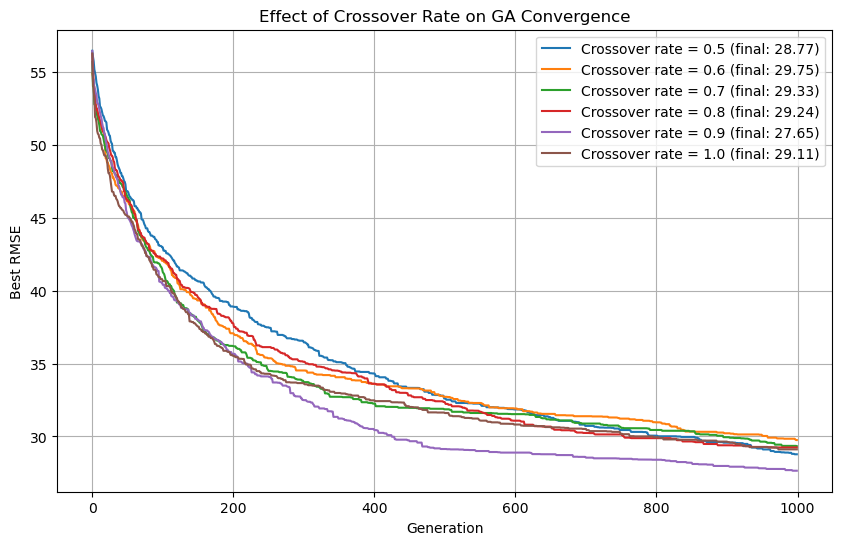

In [8]:
plt.figure(figsize=(10, 6))

for rate, result in crossover_rate_results.items():
    plt.plot(
        result["history"],
        label=f"Crossover rate = {rate} (final: {result['final_rmse']:.2f})"
    )

plt.title("Effect of Crossover Rate on GA Convergence")
plt.xlabel("Generation")
plt.ylabel("Best RMSE")
plt.legend()
plt.grid(True)
plt.show()

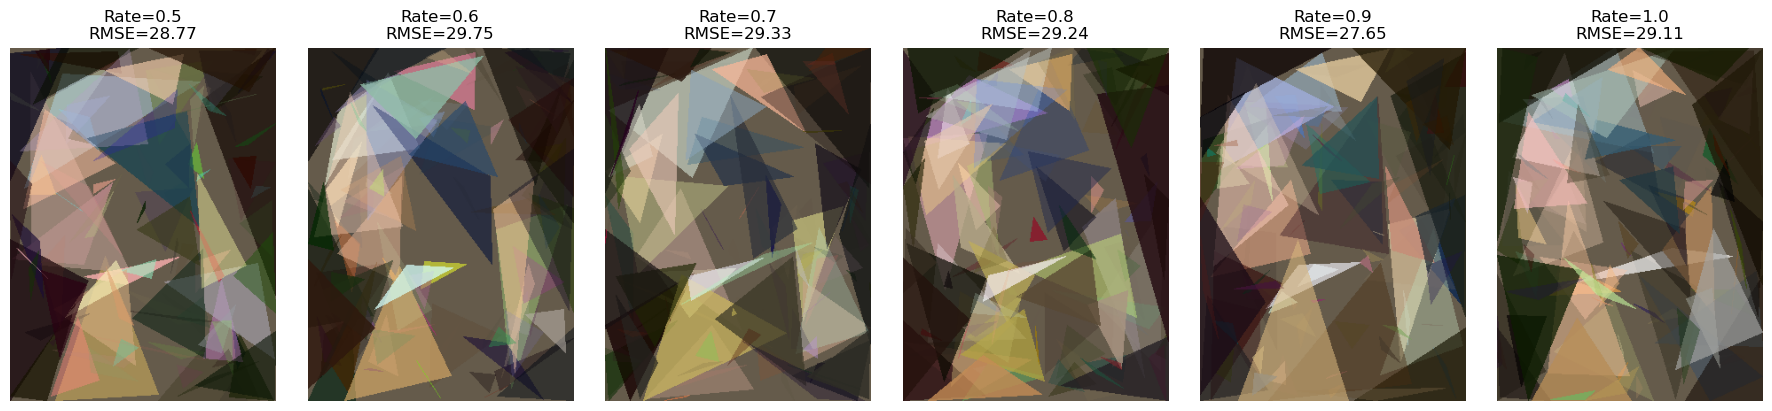

In [9]:
num_results = len(crossover_rate_results)

fig, axes = plt.subplots(1, num_results, figsize=(3 * num_results, 4))

if num_results == 1:
    axes = [axes]

for ax, (rate, result) in zip(axes, crossover_rate_results.items()):
    ax.imshow(result["final_image"])
    ax.set_title(
        f"Rate={rate}\nRMSE={result['final_rmse']:.2f}"
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

In [10]:
summary = []

for rate, result in crossover_rate_results.items():
    summary.append({
        "Crossover Rate": rate,
        "Final RMSE": result["final_rmse"],
        "Initial RMSE": result["history"][0],
        "Improvement": result["history"][0] - result["final_rmse"]
    })

summary_df = pd.DataFrame(summary)
summary_df

,Crossover Rate,Final RMSE,Initial RMSE,Improvement
0,0.5,28.774435,56.460011,27.685575
1,0.6,29.750261,54.911522,25.161261
2,0.7,29.331816,55.694218,26.362402
3,0.8,29.240952,56.232128,26.991177
4,0.9,27.645895,56.434566,28.788671
5,1.0,29.111015,56.270775,27.159760


# Results and Discussion

## Key Findings

A crossover rate of 0.9 produced the best final RMSE of 27.65, with the 
highest improvement of 28.79 points from the initial population.

Both extremes performed worse — rate 0.5 achieved 28.77 and rate 1.0 
achieved 29.11. This suggests that always applying crossover is not optimal. 
Reserving a small probability of 10% for direct parent copying helps preserve 
good solutions already found by the algorithm.

Rates between 0.6 and 0.8 produced similar results ranging from 29.24 to 
29.75, suggesting the algorithm is relatively stable in this range but 
consistently worse than 0.9.

## Convergence Behavior

The convergence curves show that rate 0.9 separates clearly from the others 
from around generation 200 onwards, converging faster and stabilizing at a 
lower RMSE. The remaining rates follow similar trajectories throughout the 
1000 generations.

Rate 0.5 starts with a higher initial RMSE but catches up over time, 
finishing as the second best result. This suggests that lower crossover 
rates allow mutation to play a stronger role in early exploration.

## Conclusion

A crossover rate of 0.9 provided the best balance between recombination 
and direct selection, achieving the lowest final RMSE of 27.65. This value 
was adopted as the default crossover rate for the final model, combined 
with uniform crossover identified as the best strategy in the CrossoverTest 
experiment.